# Tensor Reduction Analysis

Reduce higher-order interaction tensors via Frobenius norm over alphabet dimensions.

**Two modes:**
- **With APC** — for natural sequences (phylogenetic bias present)
- **Without APC** — for synthetic i.i.d. Potts-sampled sequences

This notebook loads pre-computed tensors from `results/`, which requires APC correction.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import plotly.graph_objects as go

# Data paths
RESULTS_DIR = Path("../results/20260112")

# Check what models are available
available = sorted([f.stem.replace('fields_', '') for f in RESULTS_DIR.glob('fields_*.npy')])
print(f"Available models: {available}")

MODELS = available

Available models: ['lae1', 'lae2', 'mrf1', 'mrf2', 'vae1', 'vae2']


## Load Tensors

In [2]:
# Load 0th order: fields (L, A)
fields = {m: np.load(RESULTS_DIR / f"fields_{m}.npy") for m in MODELS}
# Load 1st order: Jacobian (L, A, L, A)
jacobians = {m: np.load(RESULTS_DIR / f"jac_{m}.npy") for m in MODELS}
# Check shapes
print("Fields shapes:")
for m, f in fields.items():
    print(f"  {m}: {f.shape}")
print("\nJacobian shapes:")
for m, j in jacobians.items():
    print(f"  {m}: {j.shape}")

Fields shapes:
  lae1: (60, 20)
  lae2: (60, 20)
  mrf1: (60, 20)
  mrf2: (60, 20)
  vae1: (60, 20)
  vae2: (60, 20)

Jacobian shapes:
  lae1: (60, 20, 60, 20)
  lae2: (60, 20, 60, 20)
  mrf1: (60, 20, 60, 20)
  mrf2: (60, 20, 60, 20)
  vae1: (60, 20, 60, 20)
  vae2: (60, 20, 60, 20)


In [3]:
# Hessians are large (~7 GB each) - load selectively
# Uncomment to load a specific model's Hessian

hess_mrf1 = np.load(RESULTS_DIR / "hess_mrf1.npy")
print(f"Hessian shape: {hess_mrf1.shape}")

Hessian shape: (60, 20, 60, 20, 60, 20)


---

## Reduction Functions

### With APC (for natural sequences)

Average Product Correction removes phylogenetic bias from covariance estimates.

In [4]:
def reduce_0th_order(h):
    """Reduce (L, A) log-probabilities to (L,) field strengths.
    No APC needed for 0th order (single-site, no covariance).
    """
    return np.sqrt(np.sum(h ** 2, axis=1))

def reduce_1st_order_with_apc(J):
    """Reduce (L, A, L, A) S2-symmetric Jacobian to (L, L) with APC.
    1. Frobenius norm over alphabet dimensions
    2. Zero diagonal
    3. Apply Average Product Correction
    """
    F = np.sqrt(np.sum(J ** 2, axis=(1, 3)))
    L = F.shape[0]
    np.fill_diagonal(F, 0.0)
    row_mean = F.sum(axis=0)
    apc = np.outer(row_mean, row_mean) / row_mean.sum()
    F_apc = F - apc
    np.fill_diagonal(F_apc, 0.0)
    return F_apc

def reduce_2nd_order_with_apc(H):
    """Reduce (L, A, L, A, L, A) S3-symmetric Hessian to (L, L, L) with APC.
    1. Frobenius norm over alphabet dimensions (axes 1, 3, 5)
    2. Zero diagonal planes (i=j, j=k, i=k)
    3. Apply Average Product Correction (extended to 3D)
    """
    F = np.sqrt(np.sum(H ** 2, axis=(1, 3, 5)))
    L = F.shape[0]
    for i in range(L):
        F[i, i, :] = 0.0
        F[i, :, i] = 0.0
        F[:, i, i] = 0.0
    m0 = F.sum(axis=(1, 2))
    m1 = F.sum(axis=(0, 2))
    m2 = F.sum(axis=(0, 1))
    total = F.sum()
    apc = np.einsum('i,j,k->ijk', m0, m1, m2) / (total ** 2)
    F_apc = F - apc
    for i in range(L):
        F_apc[i, i, :] = 0.0
        F_apc[i, :, i] = 0.0
        F_apc[:, i, i] = 0.0
    return F_apc

---

## Analysis: Natural Sequences (with APC)

### 0th Order: Field Strengths

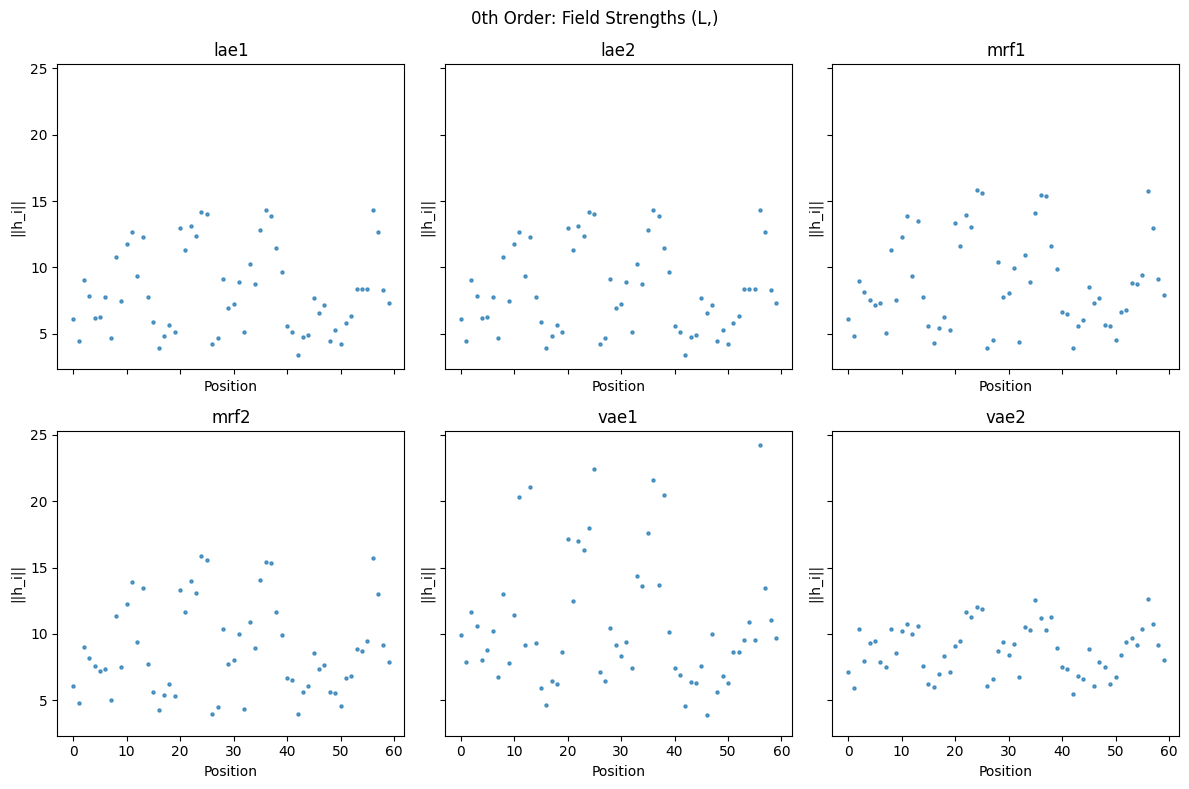

In [5]:
# Reduce fields to position-level
field_strengths = {m: reduce_0th_order(f) for m, f in fields.items()}

# Plot - dynamically size grid based on number of models
n = len(MODELS)
ncols = min(3, n)
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows), sharex=True, sharey=True)
axes = axes.flatten() if n > 1 else [axes]
for ax, m in zip(axes, MODELS):
    L = len(field_strengths[m])
    ax.scatter(range(L), field_strengths[m], s=5, alpha=0.7)
    ax.set_title(m)
    ax.set_xlabel("Position")
    ax.set_ylabel("||h_i||")
# Hide unused axes
for ax in axes[n:]:
    ax.set_visible(False)
plt.suptitle("0th Order: Field Strengths (L,)")
plt.tight_layout()
plt.show()

### 1st Order: Pairwise Couplings (with APC)

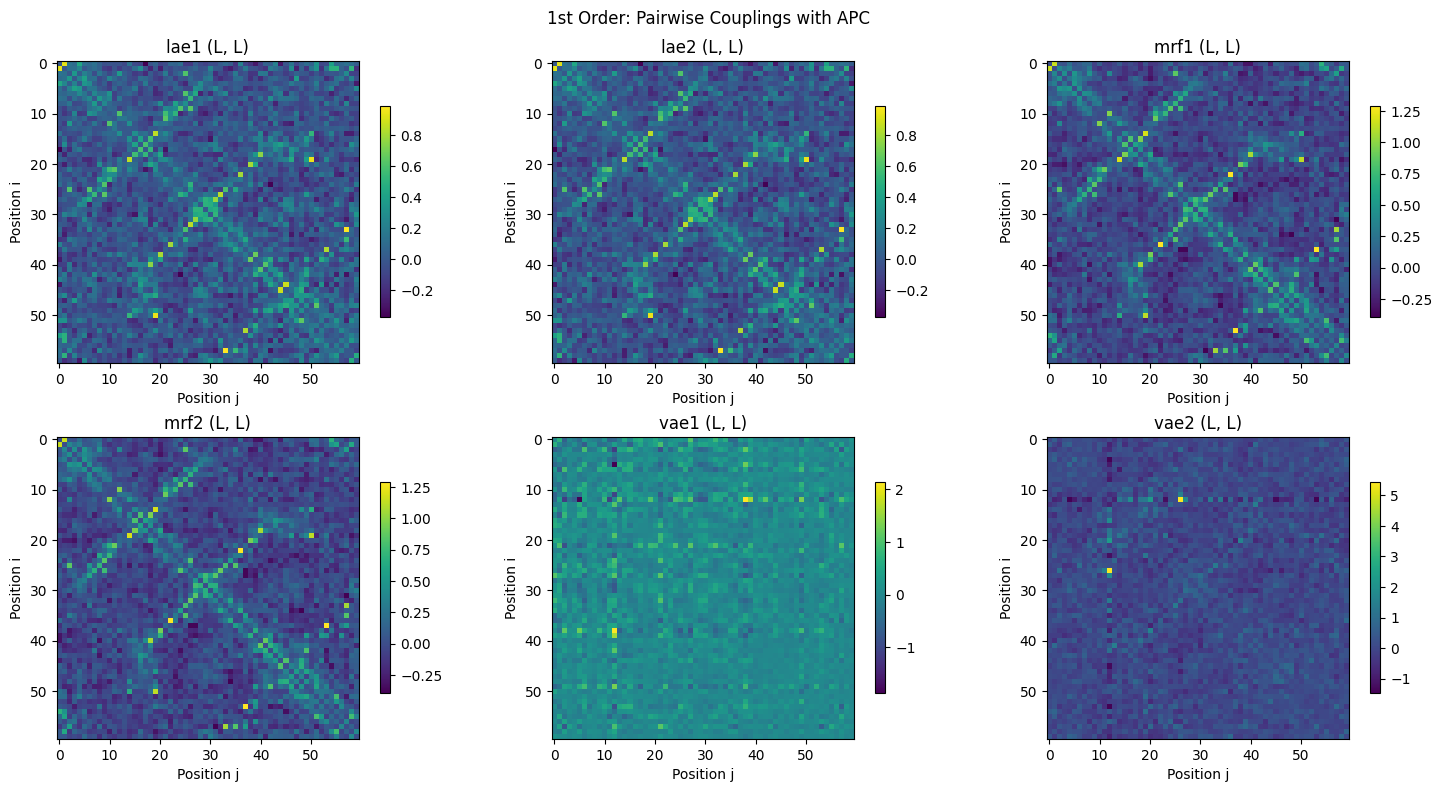

In [6]:
# Reduce Jacobians to pairwise coupling matrices
pairwise_apc = {m: reduce_1st_order_with_apc(j) for m, j in jacobians.items()}

# Plot as heatmaps - dynamically size grid
n = len(MODELS)
ncols = min(3, n)
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten() if n > 1 else [axes]
for ax, m in zip(axes, MODELS):
    im = ax.imshow(pairwise_apc[m], cmap='viridis', aspect='equal')
    ax.set_title(f"{m} (L, L)")
    ax.set_xlabel("Position j")
    ax.set_ylabel("Position i")
    plt.colorbar(im, ax=ax, shrink=0.7)
# Hide unused axes
for ax in axes[n:]:
    ax.set_visible(False)
plt.suptitle("1st Order: Pairwise Couplings with APC")
plt.tight_layout()
plt.show()

### 2nd Order: Triwise Interactions (with APC)

**Note:** Hessians are ~7 GB each. Load selectively.

Triwise shape: (60, 60, 60)


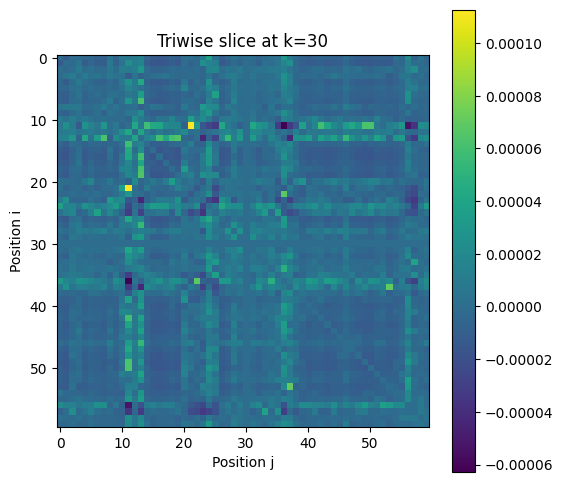

In [7]:
# Uncomment to load and reduce a Hessian

# hess = np.load(RESULTS_DIR / "hess_mrf1.npy")
triwise_apc = reduce_2nd_order_with_apc(hess_mrf1)
print(f"Triwise shape: {triwise_apc.shape}")

# Visualize a slice at position k
k = 30
plt.figure(figsize=(6, 6))
plt.imshow(triwise_apc[:, :, k], cmap='viridis')
plt.colorbar()
plt.title(f"Triwise slice at k={k}")
plt.xlabel("Position j")
plt.ylabel("Position i")
plt.show()

In [8]:
# Interactive 3D visualization of top triwise interactions
L = triwise_apc.shape[0]
N_top = L * L  # top-L² triplets

# Get indices of strongest interactions (excluding diagonal planes already zeroed)
flat_idx = np.argsort(np.abs(triwise_apc).ravel())[::-1][:N_top]
i, j, k = np.unravel_index(flat_idx, triwise_apc.shape)
vals = triwise_apc[i, j, k]

fig = go.Figure(data=[go.Scatter3d(
    x=i, y=j, z=k,
    mode='markers',
    marker=dict(
        size=3,
        color=vals,
        colorscale='Viridis',
        opacity=0.7,
        colorbar=dict(title='Strength')
    ),
    text=[f'({i_},{j_},{k_}): {v:.2e}' for i_, j_, k_, v in zip(i, j, k, vals)],
    hoverinfo='text'
)])
fig.update_layout(
    title=f'Top-{N_top} Triwise Interactions (L={L})',
    scene=dict(
        xaxis_title='Position i',
        yaxis_title='Position j',
        zaxis_title='Position k',
        aspectmode='cube'
    ),
    width=700,
    height=700
)
fig.show()

---

## Stub: Without APC (for synthetic i.i.d. sequences)

When sequences are sampled i.i.d. from a Potts model, there is no phylogenetic bias.
Therefore, no APC correction is needed — use pure Frobenius norms.

This section will be used for validation of the HOR pipeline on synthetic data.

In [ ]:
def reduce_1st_order_no_apc(J):
    """Reduce (L, A, L, A) S2-symmetric Jacobian to (L, L) without APC.
    For i.i.d. Potts-sampled sequences (no phylogenetic bias).
    """
    F = np.sqrt(np.sum(J ** 2, axis=(1, 3)))
    L = F.shape[0]
    np.fill_diagonal(F, 0.0)
    return F

def reduce_2nd_order_no_apc(H):
    """Reduce (L, A, L, A, L, A) S3-symmetric Hessian to (L, L, L) without APC.
    For i.i.d. Potts-sampled sequences (no phylogenetic bias).
    """
    F = np.sqrt(np.sum(H ** 2, axis=(1, 3, 5)))
    L = F.shape[0]
    for i in range(L):
        F[i, i, :] = 0.0
        F[i, :, i] = 0.0
        F[:, i, i] = 0.0
    return F